In [1]:
#CELL 0
!pip install numpy
!pip install sentence_transformers
!pip install pandas
!pip install sklearn
!pip install -q -U google-genai
!pip install scipy
!pip install dotenv
!pip install matplotlib


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


  Using cached sklearn-0.0.post12.tar.gz (2.6 kB)
  Installing build dependencies: started
  Installing build dependencies: finished with status 'done'
  Getting requirements to build wheel: started
  Getting requirements to build wheel: finished with status 'error'


  error: subprocess-exited-with-error
  
  × Getting requirements to build wheel did not run successfully.
  │ exit code: 1
  ╰─> [15 lines of output]
      The 'sklearn' PyPI package is deprecated, use 'scikit-learn'
      rather than 'sklearn' for pip commands.
      
      Here is how to fix this error in the main use cases:
      - use 'pip install scikit-learn' rather than 'pip install sklearn'
      - replace 'sklearn' by 'scikit-learn' in your pip requirements files
        (requirements.txt, setup.py, setup.cfg, Pipfile, etc ...)
      - if the 'sklearn' package is used by one of your dependencies,
        it would be great if you take some time to track which package uses
        'sklearn' instead of 'scikit-learn' and report it to their issue tracker
      - as a last resort, set the environment variable
        SKLEARN_ALLOW_DEPRECATED_SKLEARN_PACKAGE_INSTALL=True to avoid this error
      
      More information is available at
      https://github.com/scikit-learn/sklearn-


[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip



[notice] A new release of pip is available: 25.3 -> 26.0.1
[notice] To update, run: python.exe -m pip install --upgrade pip


In [2]:
#CELL 1
import xml.etree.ElementTree as ET
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from tqdm import tqdm
import re
from google import genai
# Optional: for correlation
from scipy.stats import pearsonr, spearmanr

from dotenv import load_dotenv
import os
load_dotenv() # Loads variables from .env


True

In [3]:
#CELL 2
def parse_nodule_xml(xml_path):
    try:
        tree = ET.parse(xml_path)
        root = tree.getroot()
        ns = {'nih': 'http://www.nih.gov'}
        
        nodules = []
        
        for nodule in root.findall('.//nih:unblindedReadNodule', ns):
            char = nodule.find('nih:characteristics', ns)
            if char is not None:
                
                def get_int(tag):
                    node = char.find(f'nih:{tag}', ns)
                    return int(node.text) if node is not None else None
                
                malig = get_int('malignancy')
                subtlety = get_int('subtlety')
                spiculation = get_int('spiculation')
                margin = get_int('margin')
                
                if malig is not None:
                    n_id = nodule.find('nih:noduleID', ns).text
                    
                    nodules.append({
                        'id': n_id,
                        'malig': malig,
                        'subtlety': subtlety,
                        'spiculation': spiculation,
                        'margin': margin
                    })
        
        return pd.DataFrame(nodules)
    
    except Exception:
        return pd.DataFrame()

In [4]:
#CELL 3
xml_root_folder = './LIDC-IDRI/'

all_dfs = []
files_found = 0

for root, dirs, files in os.walk(xml_root_folder):
    for file in files:
        if file.endswith('.xml'):
            file_path = os.path.join(root, file)
            df = parse_nodule_xml(file_path)
            
            if not df.empty:
                all_dfs.append(df)
                files_found += 1
            
            if files_found >= 50:
                break
    if files_found >= 50:
        break

raw_data = pd.concat(all_dfs, ignore_index=True)

# Aggregate per nodule
pilot_df = raw_data.groupby('id').agg(
    pi=('malig', lambda x: (x >= 3).sum() / len(x)),
    num_ratings=('malig', 'count'),
    subtlety=('subtlety', 'mean'),
    spiculation=('spiculation', 'mean'),
    margin=('margin', 'mean')
).query('num_ratings >= 4').reset_index()

# 🔥 IMPORTANT: create diversity across agreement spectrum
pilot_df = pilot_df.sort_values('pi')

pilot_df = pd.concat([
    pilot_df.head(5),   # low agreement
    pilot_df.tail(5)    # high agreement
])

print(f"Processed {len(pilot_df)} nodules (diverse π range)")
display(pilot_df.head())

Processed 10 nodules (diverse π range)


,id,pi,num_ratings,subtlety,spiculation,margin
3,2,0.200000,5,4.200000,1.400000,4.600000
2,10,0.250000,4,3.500000,1.000000,5.000000
5,4,0.250000,4,3.500000,1.250000,4.500000
12,Nodule 006,0.250000,4,3.750000,1.000000,4.750000
4,3,0.272727,11,3.545455,1.181818,4.181818


In [5]:
#CELL 4
def create_prompt(row):
    return f"""
You are a radiologist evaluating a lung nodule.

Radiological features:
- Subtlety (1–5): {row['subtlety']:.2f}
- Spiculation (1–5): {row['spiculation']:.2f}
- Margin (1–5): {row['margin']:.2f}

Higher spiculation and irregular margins are associated with malignancy.

Question:
Is this nodule malignant?

IMPORTANT:
Your confidence MUST depend on the features above. Do NOT default to a constant value.

Respond EXACTLY in this format:
Answer: <Malignant or Benign>
Confidence: <number between 0 and 100>%
Short Note (Optional and les than 10 words):

ONLY output the format.
"""

In [6]:
#CELL 5
from google import genai
import os

client_primary = genai.Client()
client_fallback = genai.Client(api_key=os.getenv("GEMINI_FALLBACK_API_KEY"))

# GLOBAL STATE (this is the key fix)
USE_FALLBACK = False


def query_model(prompt):
    global USE_FALLBACK

    # choose active client
    client = client_fallback if USE_FALLBACK else client_primary

    try:
        response = client.models.generate_content(
            model="gemini-3.1-flash-lite-preview",
            contents=prompt
        )
        print(response.text)
        return response.text

    except Exception as e:
        print("⚠️ API failure detected:", e)

        # SWITCH PERMANENTLY TO FALLBACK
        if not USE_FALLBACK:
            print("🔁 Switching permanently to FALLBACK API key...")
            USE_FALLBACK = True

        try:
            response = client_fallback.models.generate_content(
                model="gemini-3-flash-preview",
                contents=prompt
            )
            return response.text

        except Exception as e2:
            print("❌ FALLBACK ALSO FAILED:", e2)
            return None

In [7]:
#CELL 6
import re
import numpy as np

def extract_confidence(text):
    if text is None:
        return np.nan
        
    match = re.search(r'(\d{1,3})\s*%', text)
    if match:
        val = float(match.group(1))
        if 0 <= val <= 100:
            return val / 100
    
    return np.nan

In [8]:
# CELL 7 (FIXED + ROBUST)

import time
import random
from tqdm import tqdm
import numpy as np

results = []
error_logs = []

MAX_RETRIES = 4

# 🔥 Ensure prompt exists (CRITICAL FIX)
if 'prompt' not in pilot_df.columns:
    print("⚠️ 'prompt' column missing — regenerating...")
    pilot_df['prompt'] = pilot_df.apply(create_prompt, axis=1)


def safe_query(prompt, row_id):
    for attempt in range(MAX_RETRIES):
        try:
            out = query_model(prompt)

            if out is None or len(out.strip()) == 0:
                raise ValueError("EMPTY_RESPONSE")

            lower_out = out.lower()

            if any(x in lower_out for x in [
                "rate limit", "quota", "too many requests",
                "exceeded", "try again", "error"
            ]):
                raise ValueError(f"API_TEXT_ERROR: {out}")

            return out

        except Exception as e:
            wait_time = (2 ** attempt) + random.uniform(0, 1.5)
            print(f"⚠️ Retry {attempt+1}/{MAX_RETRIES} for id={row_id} | waiting {wait_time:.1f}s")
            time.sleep(wait_time)

            if attempt == MAX_RETRIES - 1:
                error_logs.append((row_id, str(e)))
                return None


for i, row in tqdm(pilot_df.iterrows(), total=len(pilot_df)):

    print("\n" + "="*60)
    print(f"CASE ID: {row['id']}")
    print(f"π (agreement): {row['pi']:.3f}")

    print("\nINPUT FEATURES:")
    print(f"Subtlety: {row['subtlety']:.2f}")
    print(f"Spiculation: {row['spiculation']:.2f}")
    print(f"Margin: {row['margin']:.2f}")

    print("\nPROMPT:")
    print(row['prompt'])

    out = safe_query(row['prompt'], row['id'])

    print("\nLLM RESPONSE:")
    print(out)

    conf = extract_confidence(out)

    print("EXTRACTED CONFIDENCE:", conf)

    results.append({
        'id': row['id'],
        'pi': row['pi'],
        'model_conf': conf
    })


results_df = pd.DataFrame(results)

print("\n✅ DONE")
print("Failures logged:", len(error_logs))
print("Valid cases:", results_df['model_conf'].notna().sum())

display(results_df.head())

⚠️ 'prompt' column missing — regenerating...


  0%|          | 0/10 [00:00<?, ?it/s]


CASE ID: 2
π (agreement): 0.200

INPUT FEATURES:
Subtlety: 4.20
Spiculation: 1.40
Margin: 4.60

PROMPT:

You are a radiologist evaluating a lung nodule.

Radiological features:
- Subtlety (1–5): 4.20
- Spiculation (1–5): 1.40
- Margin (1–5): 4.60

Higher spiculation and irregular margins are associated with malignancy.

Question:
Is this nodule malignant?

IMPORTANT:
Your confidence MUST depend on the features above. Do NOT default to a constant value.

Respond EXACTLY in this format:
Answer: <Malignant or Benign>
Confidence: <number between 0 and 100>%
Short Note (Optional and les than 10 words):

ONLY output the format.



 10%|█         | 1/10 [00:01<00:10,  1.20s/it]

Answer: Benign
Confidence: 85%
Short Note: Low spiculation and smooth margins suggest a benign etiology.

LLM RESPONSE:
Answer: Benign
Confidence: 85%
Short Note: Low spiculation and smooth margins suggest a benign etiology.
EXTRACTED CONFIDENCE: 0.85

CASE ID: 10
π (agreement): 0.250

INPUT FEATURES:
Subtlety: 3.50
Spiculation: 1.00
Margin: 5.00

PROMPT:

You are a radiologist evaluating a lung nodule.

Radiological features:
- Subtlety (1–5): 3.50
- Spiculation (1–5): 1.00
- Margin (1–5): 5.00

Higher spiculation and irregular margins are associated with malignancy.

Question:
Is this nodule malignant?

IMPORTANT:
Your confidence MUST depend on the features above. Do NOT default to a constant value.

Respond EXACTLY in this format:
Answer: <Malignant or Benign>
Confidence: <number between 0 and 100>%
Short Note (Optional and les than 10 words):

ONLY output the format.



...

 90%|█████████ | 9/10 [00:10<00:01,  1.08s/it]

Answer: Benign
Confidence: 85%
Short Note: Low spiculation and smooth margins suggest benign etiology.

LLM RESPONSE:
Answer: Benign
Confidence: 85%
Short Note: Low spiculation and smooth margins suggest benign etiology.
EXTRACTED CONFIDENCE: 0.85

CASE ID: Nodule 001
π (agreement): 0.880

INPUT FEATURES:
Subtlety: 4.16
Spiculation: 1.88
Margin: 4.08

PROMPT:

You are a radiologist evaluating a lung nodule.

Radiological features:
- Subtlety (1–5): 4.16
- Spiculation (1–5): 1.88
- Margin (1–5): 4.08

Higher spiculation and irregular margins are associated with malignancy.

Question:
Is this nodule malignant?

IMPORTANT:
Your confidence MUST depend on the features above. Do NOT default to a constant value.

Respond EXACTLY in this format:
Answer: <Malignant or Benign>
Confidence: <number between 0 and 100>%
Short Note (Optional and les than 10 words):

ONLY output the format.



100%|██████████| 10/10 [00:12<00:00,  1.21s/it]

Answer: Benign
Confidence: 78%
Short Note: Low spiculation and smooth margins suggest benign etiology.

LLM RESPONSE:
Answer: Benign
Confidence: 78%
Short Note: Low spiculation and smooth margins suggest benign etiology.
EXTRACTED CONFIDENCE: 0.78

✅ DONE
Failures logged: 0
Valid cases: 10


,id,pi,model_conf
0,2,0.200000,0.85
1,10,0.250000,0.85
2,4,0.250000,0.75
3,Nodule 006,0.250000,0.85
4,3,0.272727,0.85


In [9]:
#CELL 8
import numpy as np

results_df['pi'] = pd.to_numeric(results_df['pi'], errors='coerce')
results_df['model_conf'] = pd.to_numeric(results_df['model_conf'], errors='coerce')

print("Total cases:", len(results_df))
print("Valid confidence:", results_df['model_conf'].notna().sum())
print("Missing confidence:", results_df['model_conf'].isna().sum())

# 🔥 CRITICAL: remove broken rows
clean_df = results_df.dropna(subset=['pi', 'model_conf']).copy()

print("\nClean dataset size:", len(clean_df))

# Safety check
assert len(clean_df) >= 5, "❌ Too many failed API calls — rerun needed"

clean_df.head()

Total cases: 10
Valid confidence: 10
Missing confidence: 0

Clean dataset size: 10


,id,pi,model_conf
0,2,0.200000,0.85
1,10,0.250000,0.85
2,4,0.250000,0.75
3,Nodule 006,0.250000,0.85
4,3,0.272727,0.85


In [10]:
#CELL 9
from scipy.stats import pearsonr, spearmanr

print("📈 Correlation: Physician Agreement (π) vs Model Confidence\n")

pearson_corr, pearson_p = pearsonr(clean_df['pi'], clean_df['model_conf'])
spearman_corr, spearman_p = spearmanr(clean_df['pi'], clean_df['model_conf'])

print(f"Pearson correlation:  {pearson_corr:.4f} (p={pearson_p:.4g})")
print(f"Spearman correlation: {spearman_corr:.4f} (p={spearman_p:.4g})")

# Interpretation helper
if abs(spearman_corr) < 0.2:
    print("\n⚠️ Weak alignment: model confidence poorly tracks physician agreement")
elif abs(spearman_corr) < 0.5:
    print("\n🟡 Moderate alignment: partial uncertainty awareness")
else:
    print("\n🟢 Strong alignment: model reflects clinical uncertainty structure")

📈 Correlation: Physician Agreement (π) vs Model Confidence

Pearson correlation:  -0.2113 (p=0.5578)
Spearman correlation: -0.3262 (p=0.3576)

🟡 Moderate alignment: partial uncertainty awareness


In [11]:
#CELL 10
clean_df['PAD'] = abs(clean_df['model_conf'] - clean_df['pi'])

print("📉 PAD (Physician Agreement Distance)")
print("Mean PAD:", clean_df['PAD'].mean())
print("Std PAD:", clean_df['PAD'].std())

# Breakdown by uncertainty regimes
low = clean_df[clean_df['pi'] < 0.4]
mid = clean_df[(clean_df['pi'] >= 0.4) & (clean_df['pi'] <= 0.7)]
high = clean_df[clean_df['pi'] > 0.7]

print("\nPAD by agreement tier:")
print("Low agreement PAD :", low['PAD'].mean())
print("Mid agreement PAD :", mid['PAD'].mean())
print("High agreement PAD:", high['PAD'].mean())

📉 PAD (Physician Agreement Distance)
Mean PAD: 0.39606060606060606
Std PAD: 0.20768963918764777

PAD by agreement tier:
Low agreement PAD : 0.5854545454545454
Mid agreement PAD : 0.23333333333333334
High agreement PAD: 0.09999999999999998


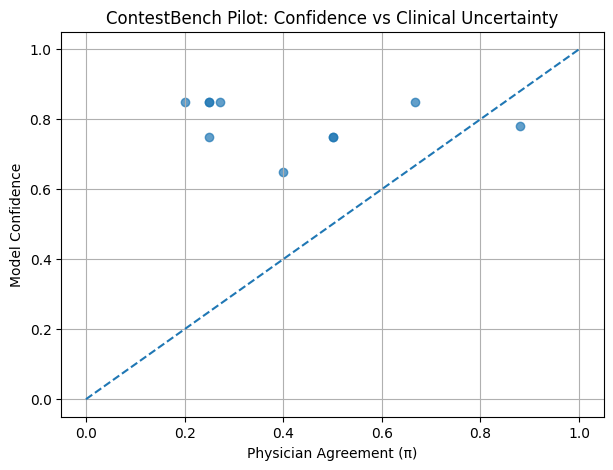

In [12]:
#CELL 11
import matplotlib.pyplot as plt

plt.figure(figsize=(7,5))

plt.scatter(
    clean_df['pi'],
    clean_df['model_conf'],
    alpha=0.7
)

# Ideal calibration line
plt.plot([0,1], [0,1], linestyle='--')

plt.xlabel("Physician Agreement (π)")
plt.ylabel("Model Confidence")
plt.title("ContestBench Pilot: Confidence vs Clinical Uncertainty")

plt.grid(True)
#CELL !@plt.show()

In [13]:
#CELL 12
low_uncertainty = clean_df[clean_df['pi'] < 0.5]
high_uncertainty = clean_df[clean_df['pi'] > 0.8]

print("🔥 Overconfidence Check")

print("Avg confidence (low agreement cases):",
      low_uncertainty['model_conf'].mean())

print("Avg confidence (high agreement cases):",
      high_uncertainty['model_conf'].mean())

🔥 Overconfidence Check
Avg confidence (low agreement cases): 0.8000000000000002
Avg confidence (high agreement cases): 0.78
